
STEP 1 : LOADING CIFAR-100 DATASET
Total Images Loaded : 5000
Image Shape         : (32, 32, 3)

STEP 2 : SENDER SIDE
Generating SHA256 hashes...
SHA256 database created.

Sender uploads clean dataset.

STEP 3 : ATTACKER INTERCEPTS DATASET
Attack Distribution
Benign Attack      : 750
BadNets Attack     : 750
TrojanNN Attack    : 750
CleanLabel Attack  : 750

Applying Benign Attacks...
Benign attacks completed.

Applying BadNets Attacks...
BadNets attacks completed.

Applying TrojanNN Attacks...
TrojanNN attacks completed.

Applying CleanLabel Attacks...
CleanLabel attacks completed.

STEP 4 : RECEIVER DOWNLOADS DATASET
Receiver downloaded tampered dataset.
Receiver does NOT know attack locations.

STEP 5 : DEFENSE 1 -> SHA256
Images Passed SHA256 : 2000
Images Failed SHA256 : 3000

Observation:
SHA256 detects every image modification,
including benign transformations.


STEP 6 : DEFENSE 2 -> SSIM
SSIM Threshold : 0.6
Accepted By SSIM : 2249
Rejected By SSIM : 751

ATTACK DETECTION RES

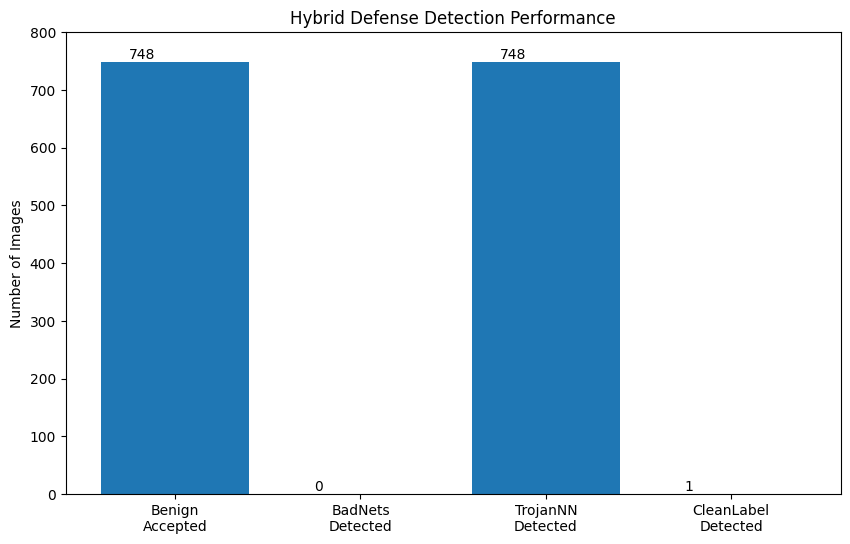


Generating Attack Distribution Pie Chart...


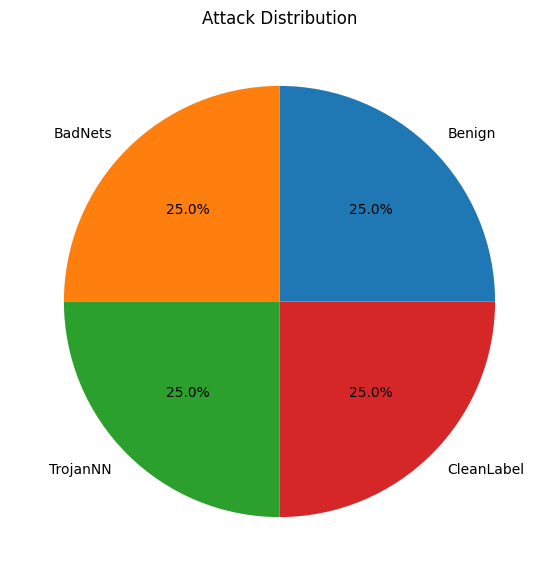


Generating SSIM Histogram...


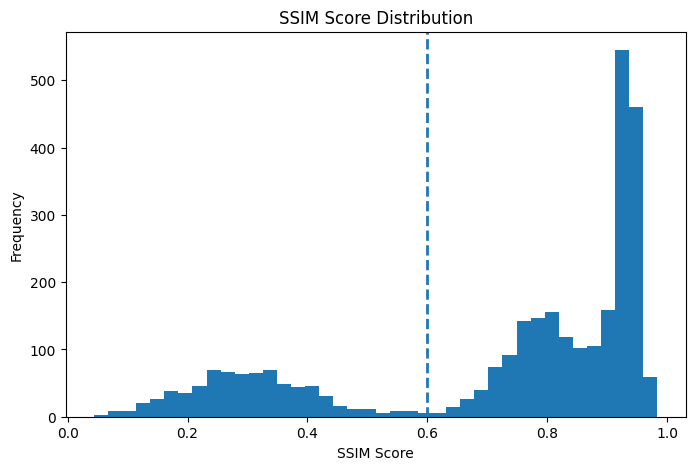


Generating Heatmap...


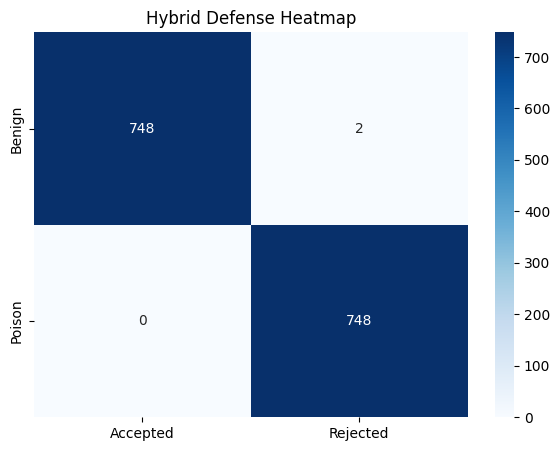


DISPLAYING VISUAL ATTACK EXAMPLES


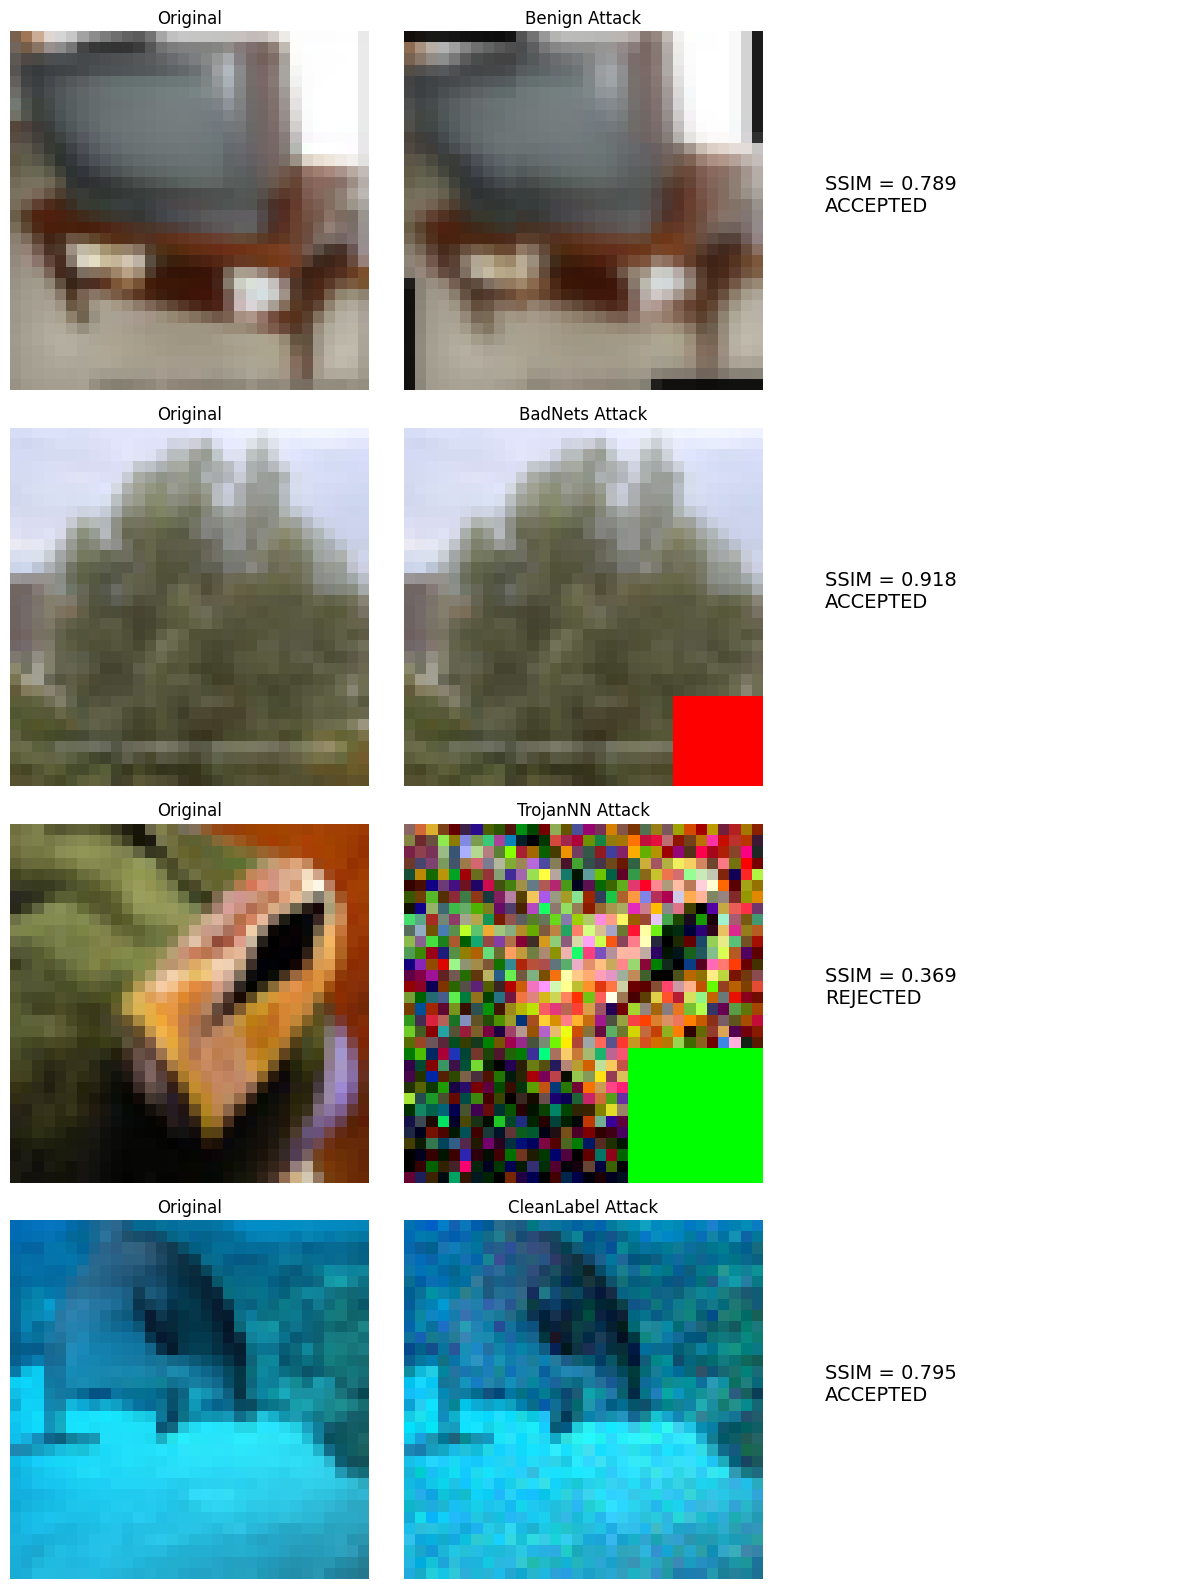


INDIVIDUAL DEFENSE FAILURE ANALYSIS

1. SHA256 Alone Fails:
   Even tiny resize/rotation changes the hash.

   Result:
   Benign images falsely rejected.


2. SSIM Alone Fails:
   Clean-label attacks maintain high similarity.

   Result:
   Sophisticated poisoning may bypass detection.


3. Hybrid Defense:
   Combines strict integrity + visual similarity.

   Result:
   Better robustness against poisoning attacks.



In [2]:
import numpy as np
import random
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from PIL import ImageFilter

from tensorflow.keras.datasets import cifar100

from skimage.metrics import structural_similarity as ssim





random.seed(42)
np.random.seed(42)



print("\n================================================")
print("STEP 1 : LOADING CIFAR-100 DATASET")
print("================================================")

(x_train, y_train), (_, _) = cifar100.load_data()

# USE 5000 IMAGES
images = x_train[:5000]
labels = y_train[:5000]

print("Total Images Loaded :", len(images))
print("Image Shape         :", images[0].shape)





def generate_hash(img):

    return hashlib.sha256(
        img.tobytes()
    ).hexdigest()




def compute_ssim(original, modified):

    score = ssim(
        original,
        modified,
        channel_axis=2,
        data_range=255
    )

    return score





def benign_attack(img):

    pil = Image.fromarray(img)

    # resize
    pil = pil.resize((28, 28))
    pil = pil.resize((32, 32))

    # rotation
    pil = pil.rotate(5)

    # blur
    pil = pil.filter(
        ImageFilter.GaussianBlur(radius=0.5)
    )

    return np.array(pil)




def badnets_attack(img):

    arr = img.copy()

    # trigger patch
    arr[24:32, 24:32] = [255, 0, 0]

    return arr





def trojannn_attack(img):

    arr = img.copy().astype(np.float32)

    # heavy gaussian noise
    noise = np.random.normal(
        0,
        60,
        arr.shape
    )

    arr += noise

    arr = np.clip(arr, 0, 255)

    arr = arr.astype(np.uint8)

    # trigger patch
    arr[20:32, 20:32] = [0, 255, 0]

    return arr




def clean_label_attack(img):

    arr = img.copy().astype(np.float32)

    noise = np.random.normal(
        0,
        10,
        arr.shape
    )

    arr += noise

    arr = np.clip(arr, 0, 255)

    return arr.astype(np.uint8)





print("\n================================================")
print("STEP 2 : SENDER SIDE")
print("================================================")

print("Generating SHA256 hashes...")

hash_database = []

for img in images:

    h = generate_hash(img)

    hash_database.append(h)

print("SHA256 database created.")

print("\nSender uploads clean dataset.")





print("\n================================================")
print("STEP 3 : ATTACKER INTERCEPTS DATASET")
print("================================================")

attacked_images = images.copy()

# SELECT 3000 IMAGES
all_indices = random.sample(
    range(5000),
    3000
)

# SPLIT ATTACKS
benign_indices = all_indices[:750]

badnets_indices = all_indices[750:1500]

trojan_indices = all_indices[1500:2250]

clean_label_indices = all_indices[2250:3000]

print("Attack Distribution")

print("Benign Attack      :", len(benign_indices))

print("BadNets Attack     :", len(badnets_indices))

print("TrojanNN Attack    :", len(trojan_indices))

print("CleanLabel Attack  :", len(clean_label_indices))





print("\nApplying Benign Attacks...")

for idx in benign_indices:

    attacked_images[idx] = benign_attack(
        attacked_images[idx]
    )

print("Benign attacks completed.")




print("\nApplying BadNets Attacks...")

for idx in badnets_indices:

    attacked_images[idx] = badnets_attack(
        attacked_images[idx]
    )

print("BadNets attacks completed.")





print("\nApplying TrojanNN Attacks...")

for idx in trojan_indices:

    attacked_images[idx] = trojannn_attack(
        attacked_images[idx]
    )

print("TrojanNN attacks completed.")





print("\nApplying CleanLabel Attacks...")

for idx in clean_label_indices:

    attacked_images[idx] = clean_label_attack(
        attacked_images[idx]
    )

print("CleanLabel attacks completed.")




print("\n================================================")
print("STEP 4 : RECEIVER DOWNLOADS DATASET")
print("================================================")

received_images = attacked_images.copy()

print("Receiver downloaded tampered dataset.")

print("Receiver does NOT know attack locations.")





print("\n================================================")
print("STEP 5 : DEFENSE 1 -> SHA256")
print("================================================")

hash_pass = []
hash_fail = []

for i in range(5000):

    current_hash = generate_hash(
        received_images[i]
    )

    if current_hash == hash_database[i]:

        hash_pass.append(i)

    else:

        hash_fail.append(i)

print("Images Passed SHA256 :", len(hash_pass))

print("Images Failed SHA256 :", len(hash_fail))

print("""
Observation:
SHA256 detects every image modification,
including benign transformations.
""")





print("\n================================================")
print("STEP 6 : DEFENSE 2 -> SSIM")
print("================================================")

THRESHOLD = 0.60

ssim_accept = []
ssim_reject = []

all_scores = []

for idx in hash_fail:

    score = compute_ssim(
        images[idx],
        received_images[idx]
    )

    all_scores.append(score)

    if score >= THRESHOLD:

        ssim_accept.append(idx)

    else:

        ssim_reject.append(idx)

print("SSIM Threshold :", THRESHOLD)

print("Accepted By SSIM :", len(ssim_accept))

print("Rejected By SSIM :", len(ssim_reject))




print("\n================================================")
print("ATTACK DETECTION RESULTS")
print("================================================")





benign_accepted = len(
    set(benign_indices).intersection(
        set(ssim_accept)
    )
)

benign_rejected = len(
    set(benign_indices).intersection(
        set(ssim_reject)
    )
)





badnets_detected = len(
    set(badnets_indices).intersection(
        set(ssim_reject)
    )
)

badnets_bypassed = len(
    set(badnets_indices).intersection(
        set(ssim_accept)
    )
)





trojan_detected = len(
    set(trojan_indices).intersection(
        set(ssim_reject)
    )
)

trojan_bypassed = len(
    set(trojan_indices).intersection(
        set(ssim_accept)
    )
)





clean_detected = len(
    set(clean_label_indices).intersection(
        set(ssim_reject)
    )
)

clean_bypassed = len(
    set(clean_label_indices).intersection(
        set(ssim_accept)
    )
)





print("------------------------------------------------")
print("BENIGN TRANSFORMATION RESULTS")
print("------------------------------------------------")

print("Benign Accepted Correctly :", benign_accepted, "/750")

print("Benign Rejected Wrongly   :", benign_rejected, "/750")



print("\n------------------------------------------------")
print("BADNETS ATTACK RESULTS")
print("------------------------------------------------")

print("BadNets Detected          :", badnets_detected, "/750")

print("BadNets Bypassed Defense  :", badnets_bypassed, "/750")



print("\n------------------------------------------------")
print("TROJANNN ATTACK RESULTS")
print("------------------------------------------------")

print("TrojanNN Detected         :", trojan_detected, "/750")

print("TrojanNN Bypassed Defense :", trojan_bypassed, "/750")



print("\n------------------------------------------------")
print("CLEAN LABEL ATTACK RESULTS")
print("------------------------------------------------")

print("CleanLabel Detected       :", clean_detected, "/750")

print("CleanLabel Bypassed       :", clean_bypassed, "/750")





fpr = (
    benign_rejected / len(benign_indices)
) * 100

print("\n------------------------------------------------")
print("FALSE POSITIVE RATE")
print("------------------------------------------------")

print("False Positive Rate : {:.2f}%".format(fpr))

print("""
False Positive Meaning:
Legitimate benign images
incorrectly classified as poisoned.
""")





print("\nGenerating Detection Bar Chart...")

attack_names = [
    "Benign\nAccepted",
    "BadNets\nDetected",
    "TrojanNN\nDetected",
    "CleanLabel\nDetected"
]

values = [
    benign_accepted,
    badnets_detected,
    trojan_detected,
    clean_detected
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    attack_names,
    values
)

plt.title(
    "Hybrid Defense Detection Performance"
)

plt.ylabel(
    "Number of Images"
)

plt.ylim(0, 800)

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + 0.15,
        yval + 5,
        yval
    )

plt.show()





print("\nGenerating Attack Distribution Pie Chart...")

sizes = [
    len(benign_indices),
    len(badnets_indices),
    len(trojan_indices),
    len(clean_label_indices)
]

labels_chart = [
    "Benign",
    "BadNets",
    "TrojanNN",
    "CleanLabel"
]

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels_chart,
    autopct='%1.1f%%'
)

plt.title(
    "Attack Distribution"
)

plt.show()





print("\nGenerating SSIM Histogram...")

plt.figure(figsize=(8,5))

plt.hist(
    all_scores,
    bins=40
)

plt.axvline(
    THRESHOLD,
    linestyle='--',
    linewidth=2
)

plt.title(
    "SSIM Score Distribution"
)

plt.xlabel(
    "SSIM Score"
)

plt.ylabel(
    "Frequency"
)

plt.show()





print("\nGenerating Heatmap...")

heatmap_data = np.array([

    [benign_accepted, benign_rejected],

    [badnets_detected, trojan_detected]

])

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Accepted", "Rejected"],
    yticklabels=["Benign", "Poison"]
)

plt.title(
    "Hybrid Defense Heatmap"
)

plt.show()





print("\n================================================")
print("DISPLAYING VISUAL ATTACK EXAMPLES")
print("================================================")

b = benign_indices[0]
bn = badnets_indices[0]
tr = trojan_indices[0]
cl = clean_label_indices[0]

fig, axes = plt.subplots(
    4,
    3,
    figsize=(12,16)
)

examples = [

    ("Benign Attack", b),

    ("BadNets Attack", bn),

    ("TrojanNN Attack", tr),

    ("CleanLabel Attack", cl)
]

for row, (name, idx) in enumerate(examples):

    # original image
    axes[row,0].imshow(images[idx])

    axes[row,0].set_title(
        "Original"
    )

    axes[row,0].axis("off")


    # attacked image
    axes[row,1].imshow(received_images[idx])

    axes[row,1].set_title(
        name
    )

    axes[row,1].axis("off")


    # SSIM result
    score = compute_ssim(
        images[idx],
        received_images[idx]
    )

    if score >= THRESHOLD:

        decision = "ACCEPTED"

    else:

        decision = "REJECTED"

    axes[row,2].text(
        0.1,
        0.5,
        "SSIM = {:.3f}\n{}".format(
            score,
            decision
        ),
        fontsize=14
    )

    axes[row,2].axis("off")

plt.tight_layout()

plt.show()





print("\n================================================")
print("INDIVIDUAL DEFENSE FAILURE ANALYSIS")
print("================================================")

print("""
1. SHA256 Alone Fails:
   Even tiny resize/rotation changes the hash.

   Result:
   Benign images falsely rejected.


2. SSIM Alone Fails:
   Clean-label attacks maintain high similarity.

   Result:
   Sophisticated poisoning may bypass detection.


3. Hybrid Defense:
   Combines strict integrity + visual similarity.

   Result:
   Better robustness against poisoning attacks.
""")
